<a href="https://colab.research.google.com/github/N15H7HA/Shakespeare-Sentiment-Analysis/blob/main/MRI_Final_Accuracy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MRI Brain Tumor Detection
## Contourlet Transform + PCA + SVM + WOA

Based on: *Farzamnia et al., IEEE Access, 2023*

**Dataset:** `ahmedhamada0/brain-tumor-detection` — 3000 images (yes/no)

**Pipeline (exact paper steps):**
1. Daubechies wavelet denoising (db4, 3 levels, soft threshold)
2. Otsu segmentation (remove segments < 80 pixels)
3. Contourlet PDFB decomposition → GLCM → 13 statistical features
4. PCA dimensionality reduction
5. WOA optimises SVM C and gamma
6. SVM RBF classifier → Benign / Malignant
7. Output matches paper Figure 9(a)

In [1]:
!pip install kagglehub opencv-python pywavelets scikit-learn matplotlib seaborn scipy numpy -q

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import kagglehub
import os
import cv2
import numpy as np
import pywt
import warnings
warnings.filterwarnings('ignore')

dataset_path = kagglehub.dataset_download('ahmedhamada0/brain-tumor-detection')
print('Dataset path:', dataset_path)
for root, dirs, files in os.walk(dataset_path):
    print(root, '->', len(files), 'files')

100%|██████████| 84.0M/84.0M [00:01<00:00, 69.6MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/ahmedhamada0/brain-tumor-detection/versions/12
/root/.cache/kagglehub/datasets/ahmedhamada0/brain-tumor-detection/versions/12 -> 0 files
/root/.cache/kagglehub/datasets/ahmedhamada0/brain-tumor-detection/versions/12/Br35H-Mask-RCNN -> 1 files
/root/.cache/kagglehub/datasets/ahmedhamada0/brain-tumor-detection/versions/12/Br35H-Mask-RCNN/TEST -> 101 files
/root/.cache/kagglehub/datasets/ahmedhamada0/brain-tumor-detection/versions/12/Br35H-Mask-RCNN/VAL -> 202 files
/root/.cache/kagglehub/datasets/ahmedhamada0/brain-tumor-detection/versions/12/Br35H-Mask-RCNN/TRAIN -> 501 files
/root/.cache/kagglehub/datasets/ahmedhamada0/brain-tumor-detection/versions/12/yes -> 1500 files
/root/.cache/kagglehub/datasets/ahmedhamada0/brain-tumor-detection/versions/12/pred -> 60 files
/root/.cache/kagglehub/datasets/ahmedhamada0/brain-tumor-detection/versions/12/no -> 1500 files


## Step 1 — Preprocessing
Paper: *Daubechies wavelet, 3-level decomposition, soft thresholding, 256×256 greyscale*

In [4]:
def wavelet_denoise(img, wavelet='db4', level=3):
    """
    Soft-threshold wavelet denoising.
    Paper: Daubechies, 3 levels, soft thresholding.
    """
    coeffs      = pywt.wavedec2(img, wavelet=wavelet, level=level)
    detail_flat = np.concatenate([c.flatten() for tup in coeffs[1:] for c in tup])
    sigma       = np.median(np.abs(detail_flat)) / 0.6745
    threshold   = sigma * np.sqrt(2 * np.log(max(img.size, 1)))

    new_coeffs = [coeffs[0]]
    for detail_tuple in coeffs[1:]:
        new_coeffs.append(tuple(
            pywt.threshold(np.nan_to_num(d, nan=0.0), threshold, mode='soft')
            for d in detail_tuple
        ))

    recon = pywt.waverec2(new_coeffs, wavelet=wavelet)
    recon = np.nan_to_num(recon, nan=0.0, posinf=1.0, neginf=0.0)
    return np.clip(recon, 0.0, 1.0).astype(np.float32)


def preprocess_mri(img_path, size=256):
    """
    Load → greyscale → resize 256×256 → wavelet denoise.
    Paper spec: 256×256, grey levels, MRI.
    """
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f'Cannot read: {img_path}')
    gray     = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    resized  = cv2.resize(gray, (size, size))
    normed   = resized.astype(np.float32) / 255.0
    denoised = wavelet_denoise(normed)
    if denoised.shape != (size, size):
        denoised = cv2.resize(denoised, (size, size))
    return denoised


print('Step 1 defined.')

Step 1 defined.


## Step 2 — Otsu Segmentation
Paper: *Otsu thresholding, segments < 80 pixels removed*

In [5]:
def otsu_segment(img):
    """
    Otsu thresholding. Connected components < 80 pixels removed.
    """
    clean   = np.clip(np.nan_to_num(img, nan=0.0), 0.0, 1.0)
    uint8   = (clean * 255).astype(np.uint8)
    _, bin_ = cv2.threshold(uint8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(bin_, connectivity=8)
    mask = np.zeros_like(bin_)
    for i in range(1, n_labels):
        if stats[i, cv2.CC_STAT_AREA] >= 80:
            mask[labels == i] = 255

    mask_f    = mask.astype(np.float32) / 255.0
    segmented = clean * mask_f
    return segmented, mask_f


print('Step 2 defined.')

Step 2 defined.


## Step 3 — Contourlet Feature Extraction → GLCM → 13 Features

Paper: *PDFB, 7-9 pyramidal filter, pkva directional filter,
4 pyramid levels, directions (coarse→fine): 0, 3, 3, 4*

Extracts exactly the 13 features from paper Table 5:
Mean, SD, Entropy, RMS, Variance, Smoothness, Kurtosis,
Skewness, IDM, Contrast, Correlation, Energy, Homogeneity

In [6]:
from scipy.stats import kurtosis, skew


def build_glcm(patch, levels=16):
    """Symmetric horizontal GLCM."""
    lo, hi = patch.min(), patch.max()
    if hi - lo < 1e-10:
        g = np.zeros((levels, levels))
        g[0, 0] = 1.0
        return g
    q    = ((patch - lo) / (hi - lo) * (levels - 1)).astype(np.uint8)
    glcm = np.zeros((levels, levels), dtype=np.float64)
    r, c = q.shape
    for row in range(r):
        for col in range(c - 1):
            i, j = int(q[row, col]), int(q[row, col + 1])
            glcm[i, j] += 1
            glcm[j, i] += 1
    s = glcm.sum()
    return glcm / s if s > 0 else glcm


def extract_13_features(subband):
    """Extract exactly the 13 GLCM features from paper Table 5."""
    flat = subband.flatten().astype(np.float64)
    flat = flat[np.isfinite(flat)]
    if len(flat) < 4:
        return [0.0] * 13

    # Statistical features
    mean       = float(np.mean(flat))
    sd         = float(np.std(flat))
    variance   = float(np.var(flat))
    rms        = float(np.sqrt(np.mean(flat ** 2)))
    smoothness = float(1.0 - 1.0 / (1.0 + variance))
    sk         = float(skew(flat))
    kurt_val   = float(kurtosis(flat, fisher=False))
    prob       = np.abs(flat) / (np.abs(flat).sum() + 1e-12)
    entropy    = float(-np.sum(prob * np.log2(prob + 1e-12)))

    # GLCM features
    side = min(64, int(np.sqrt(len(flat))))
    glcm = build_glcm(flat[:side * side].reshape(side, side), levels=16)
    idx  = np.arange(16)
    ig, jg = np.meshgrid(idx, idx, indexing='ij')

    contrast    = float(np.sum(glcm * (ig - jg) ** 2))
    energy      = float(np.sum(glcm ** 2))
    homogeneity = float(np.sum(glcm / (1.0 + np.abs(ig - jg))))
    idm         = float(np.sum(glcm / (1.0 + (ig - jg) ** 2)))
    mu_i  = float(np.sum(ig * glcm))
    mu_j  = float(np.sum(jg * glcm))
    sig_i = float(np.sqrt(np.sum(glcm * (ig - mu_i) ** 2)))
    sig_j = float(np.sqrt(np.sum(glcm * (jg - mu_j) ** 2)))
    corr  = (
        float(np.sum(glcm * (ig - mu_i) * (jg - mu_j)) / (sig_i * sig_j))
        if sig_i * sig_j > 1e-10 else 0.0
    )

    return [mean, sd, entropy, rms, variance,
            smoothness, kurt_val, sk, idm,
            contrast, corr, energy, homogeneity]


def contourlet_features(img):
    """
    Simulate PDFB contourlet decomposition using db7 wavelet.
    4 pyramid levels, directions (finest→coarsest): 4, 3, 3, 0.
    Extracts 13 GLCM features per subband.
    Total features = (1 + 4 + 3 + 3 + 1) * 13 = 156
    """
    features   = []
    coeffs     = pywt.wavedec2(img, wavelet='db7', level=4)
    directions = [4, 3, 3, 0]  # finest to coarsest

    # Approximation subband (coarsest, 0 directional decompositions)
    features.extend(extract_13_features(coeffs[0]))

    # Detail subbands
    for lvl, (cH, cV, cD) in enumerate(coeffs[1:]):
        n_dirs = directions[lvl]
        if n_dirs == 0:
            combined = np.sqrt(np.clip(cH**2 + cV**2 + cD**2, 0, None))
            features.extend(extract_13_features(combined))
        else:
            for d in range(n_dirs):
                angle = d * np.pi / n_dirs
                dir_sub = (
                    np.cos(angle) ** 2 * cH +
                    np.sin(angle) ** 2 * cV +
                    np.cos(angle) * np.sin(angle) * cD
                )
                features.extend(extract_13_features(dir_sub))

    return np.array(features, dtype=np.float32)


# Quick test
import glob
samples = (
    glob.glob(dataset_path + '/yes/*.jpg') +
    glob.glob(dataset_path + '/yes/*.JPG') +
    glob.glob(dataset_path + '/yes/*.jpeg')
)
if samples:
    _img  = preprocess_mri(samples[0])
    _seg, _ = otsu_segment(_img)
    _feat = contourlet_features(_seg)
    print(f'Feature vector length: {len(_feat)}')
else:
    print('No sample found — check dataset path')

Feature vector length: 156


## Step 4 — Load Full Dataset (3000 images)

In [7]:
from tqdm.auto import tqdm


def load_dataset(dataset_path):
    X, y  = [], []
    exts  = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')

    for label, folder_name in [(1, 'yes'), (0, 'no')]:
        folder = os.path.join(dataset_path, folder_name)
        files  = [f for f in os.listdir(folder) if f.endswith(exts)]
        tag    = 'Malignant' if label == 1 else 'Benign'
        print(f'{tag}: {len(files)} images')

        for fname in tqdm(files, desc=tag):
            try:
                img      = preprocess_mri(os.path.join(folder, fname))
                seg, _   = otsu_segment(img)
                feat     = contourlet_features(seg)
                if np.all(np.isfinite(feat)):
                    X.append(feat)
                    y.append(label)
            except Exception as e:
                print(f'  Skipping {fname}: {e}')

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)


print('Loading dataset...')
X, y = load_dataset(dataset_path)
print(f'Total: {X.shape[0]} samples, {X.shape[1]} features')
print(f'Malignant: {np.sum(y==1)}   Benign: {np.sum(y==0)}')

Loading dataset...
Malignant: 1500 images


Malignant:   0%|          | 0/1500 [00:00<?, ?it/s]

Benign: 1500 images


Benign:   0%|          | 0/1500 [00:00<?, ?it/s]

Total: 3000 samples, 156 features
Malignant: 1500   Benign: 1500


## Step 5 — StandardScaler + PCA + 70/30 Split
Paper: *70% training, 30% test, PCA for dimensionality reduction*

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# 70/30 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
print(f'Train: {X_train.shape[0]}   Test: {X_test.shape[0]}')

# Scale
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_test_scaled  = np.nan_to_num(X_test_scaled,  nan=0.0, posinf=0.0, neginf=0.0)

# PCA
N_COMPONENTS = min(80, X_train_scaled.shape[1], X_train_scaled.shape[0] - 1)
pca          = PCA(n_components=N_COMPONENTS, random_state=42)
X_train_pca  = pca.fit_transform(X_train_scaled)
X_test_pca   = pca.transform(X_test_scaled)

explained = pca.explained_variance_ratio_.sum() * 100
print(f'PCA: {N_COMPONENTS} components → {explained:.1f}% variance explained')
print(f'PCA shape: {X_train_pca.shape}')

Train: 2100   Test: 900
PCA: 80 components → 99.7% variance explained
PCA shape: (2100, 80)


## Step 6 — WOA Optimises SVM Hyperparameters
Paper: *WOA used to optimise classifier. Max iter=100, a=0.5→0, b=1*

In [9]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


def evaluate_svm(params, X_tr, y_tr, X_val, y_val):
    C     = float(np.clip(params[0], 0.01, 1000.0))
    gamma = float(np.clip(params[1], 1e-5, 10.0))
    try:
        clf = SVC(kernel='rbf', C=C, gamma=gamma,
                  class_weight='balanced', random_state=42)
        clf.fit(X_tr, y_tr)
        return accuracy_score(y_val, clf.predict(X_val))
    except Exception:
        return 0.0


def whale_optimization(X_tr, y_tr, X_val, y_val,
                        n_whales=10, max_iter=100,
                        lb=[0.01, 1e-5],
                        ub=[1000.0, 10.0]):
    """
    True WOA (Mirjalili & Lewis, 2016).
    3 phases: encircling prey, bubble-net spiral, random search.
    Optimises SVM C and gamma.
    """
    dim  = len(lb)
    lb   = np.array(lb,  dtype=float)
    ub   = np.array(ub,  dtype=float)

    # Initialise population
    positions = lb + np.random.rand(n_whales, dim) * (ub - lb)
    scores    = np.array([
        evaluate_svm(p, X_tr, y_tr, X_val, y_val) for p in positions
    ])

    best_idx   = int(np.argmax(scores))
    best_pos   = positions[best_idx].copy()
    best_score = scores[best_idx]
    history    = [best_score]

    print(f'WOA start — acc: {best_score:.4f}  C: {best_pos[0]:.4f}  gamma: {best_pos[1]:.6f}')

    for t in range(max_iter):
        a  = 2.0 - 2.0 * (t / max_iter)   # 2 → 0
        a2 = -1.0 - (t / max_iter)         # -1 → -2

        for i in range(n_whales):
            r1, r2 = np.random.rand(dim), np.random.rand(dim)
            A      = 2 * a * r1 - a
            C_vec  = 2 * r2
            p      = np.random.rand()

            if p < 0.5:
                if np.linalg.norm(A) < 1:
                    # Phase 1: Encircling prey
                    D            = np.abs(C_vec * best_pos - positions[i])
                    positions[i] = best_pos - A * D
                else:
                    # Phase 3: Random search
                    ri           = np.random.randint(0, n_whales)
                    D            = np.abs(C_vec * positions[ri] - positions[i])
                    positions[i] = positions[ri] - A * D
            else:
                # Phase 2: Bubble-net spiral
                l            = (a2 - 1) * np.random.rand(dim) + 1
                D_prime      = np.abs(best_pos - positions[i])
                positions[i] = (D_prime * np.exp(1.0 * l) *
                                np.cos(2 * np.pi * l) + best_pos)

            positions[i] = np.clip(positions[i], lb, ub)

        # Evaluate updated positions
        for i in range(n_whales):
            s = evaluate_svm(positions[i], X_tr, y_tr, X_val, y_val)
            if s > best_score:
                best_score = s
                best_pos   = positions[i].copy()

        history.append(best_score)
        if (t + 1) % 10 == 0:
            print(f'  iter {t+1:3d}/{max_iter}  '
                  f'acc: {best_score:.4f}  '
                  f'C: {best_pos[0]:.3f}  '
                  f'gamma: {best_pos[1]:.5f}')

    return best_pos, best_score, history


print('WOA defined.')

WOA defined.


## Step 7 — Run WOA

In [10]:
from sklearn.model_selection import train_test_split as tts

np.random.seed(42)

# Internal validation split — test set stays completely unseen
X_woa_tr, X_woa_val, y_woa_tr, y_woa_val = tts(
    X_train_pca, y_train,
    test_size=0.2, stratify=y_train, random_state=42
)

print('Running WOA...')
best_params, best_val_acc, woa_history = whale_optimization(
    X_woa_tr, y_woa_tr,
    X_woa_val, y_woa_val,
    n_whales = 10,
    max_iter = 100,
    lb       = [0.01,  1e-5],
    ub       = [1000.0, 10.0]
)

best_C     = float(np.clip(best_params[0], 0.01, 1000.0))
best_gamma = float(np.clip(best_params[1], 1e-5, 10.0))

print(f'\n=== WOA RESULT ===')
print(f'Best validation accuracy : {best_val_acc:.4f}')
print(f'Best C                   : {best_C:.4f}')
print(f'Best gamma               : {best_gamma:.6f}')

Running WOA...
WOA start — acc: 0.6500  C: 156.0271  gamma: 1.559954
  iter  10/100  acc: 0.9595  C: 415.630  gamma: 0.00298
  iter  20/100  acc: 0.9619  C: 174.540  gamma: 0.00571
  iter  30/100  acc: 0.9643  C: 38.027  gamma: 0.00263
  iter  40/100  acc: 0.9643  C: 38.027  gamma: 0.00263
  iter  50/100  acc: 0.9643  C: 38.027  gamma: 0.00263
  iter  60/100  acc: 0.9643  C: 38.027  gamma: 0.00263
  iter  70/100  acc: 0.9643  C: 38.027  gamma: 0.00263
  iter  80/100  acc: 0.9643  C: 38.027  gamma: 0.00263
  iter  90/100  acc: 0.9643  C: 38.027  gamma: 0.00263
  iter 100/100  acc: 0.9643  C: 38.027  gamma: 0.00263

=== WOA RESULT ===
Best validation accuracy : 0.9643
Best C                   : 38.0267
Best gamma               : 0.002633


## Step 8 — Train Final SVM on Full Training Data

In [11]:
print('Training final SVM...')
final_clf = SVC(
    kernel       = 'rbf',
    C            = best_C,
    gamma        = best_gamma,
    class_weight = 'balanced',
    probability  = True,
    random_state = 42
)
final_clf.fit(X_train_pca, y_train)
print('SVM training complete.')

Training final SVM...
SVM training complete.


## Step 9 — Evaluation


  Accuracy : 0.9622  (96.22%)
  Recall   : 0.9578
  MSE      : 0.0378
              precision    recall  f1-score   support

      Benign       0.96      0.97      0.96       450
   Malignant       0.97      0.96      0.96       450

    accuracy                           0.96       900
   macro avg       0.96      0.96      0.96       900
weighted avg       0.96      0.96      0.96       900



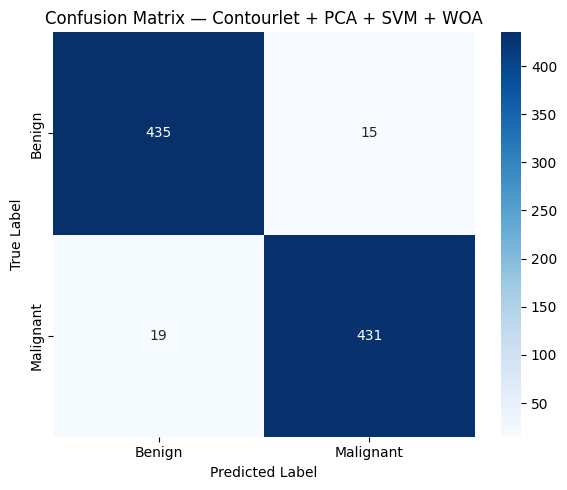

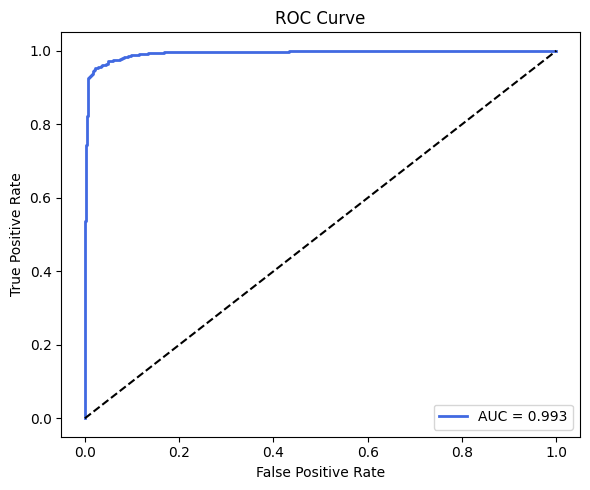

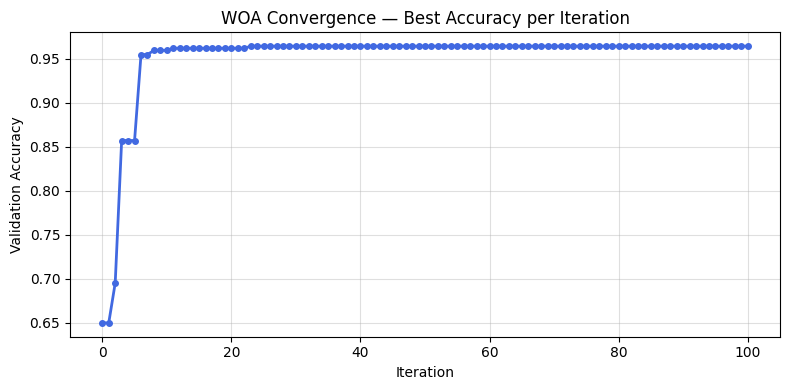

In [12]:
from sklearn.metrics import (
    accuracy_score, recall_score, mean_squared_error,
    classification_report, confusion_matrix, roc_curve, auc
)
import matplotlib.pyplot as plt
import seaborn as sns

y_pred      = final_clf.predict(X_test_pca)
y_pred_prob = final_clf.predict_proba(X_test_pca)[:, 1]

acc    = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred, zero_division=0)
mse    = mean_squared_error(y_test, y_pred)

print(f"\n{'='*50}")
print(f'  Accuracy : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Recall   : {recall:.4f}')
print(f'  MSE      : {mse:.4f}')
print(f"{'='*50}")
print(classification_report(y_test, y_pred,
                             target_names=['Benign', 'Malignant']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix — Contourlet + PCA + SVM + WOA')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc     = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='royalblue', lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

# WOA Convergence
plt.figure(figsize=(8, 4))
plt.plot(woa_history, marker='o', linewidth=2, markersize=4, color='royalblue')
plt.title('WOA Convergence — Best Accuracy per Iteration')
plt.xlabel('Iteration')
plt.ylabel('Validation Accuracy')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## Step 10 — Save Model

In [13]:
import pickle

project_path = '/content/drive/MyDrive/brain_tumor_project'
os.makedirs(project_path, exist_ok=True)

model_bundle = {
    'scaler'     : scaler,
    'pca'        : pca,
    'clf'        : final_clf,
    'classes'    : ['Benign', 'Malignant'],
    'best_C'     : best_C,
    'best_gamma' : best_gamma,
    'accuracy'   : acc
}

save_path = os.path.join(project_path, 'contourlet_svm_woa_model.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(model_bundle, f)

print(f'Model saved: {save_path}')
print(f'Final accuracy: {acc*100:.2f}%')

Model saved: /content/drive/MyDrive/brain_tumor_project/contourlet_svm_woa_model.pkl
Final accuracy: 96.22%


## Step 11 — Inference
Matches paper Figure 9(a): original MRI + segmented image + 13 features + prediction label.

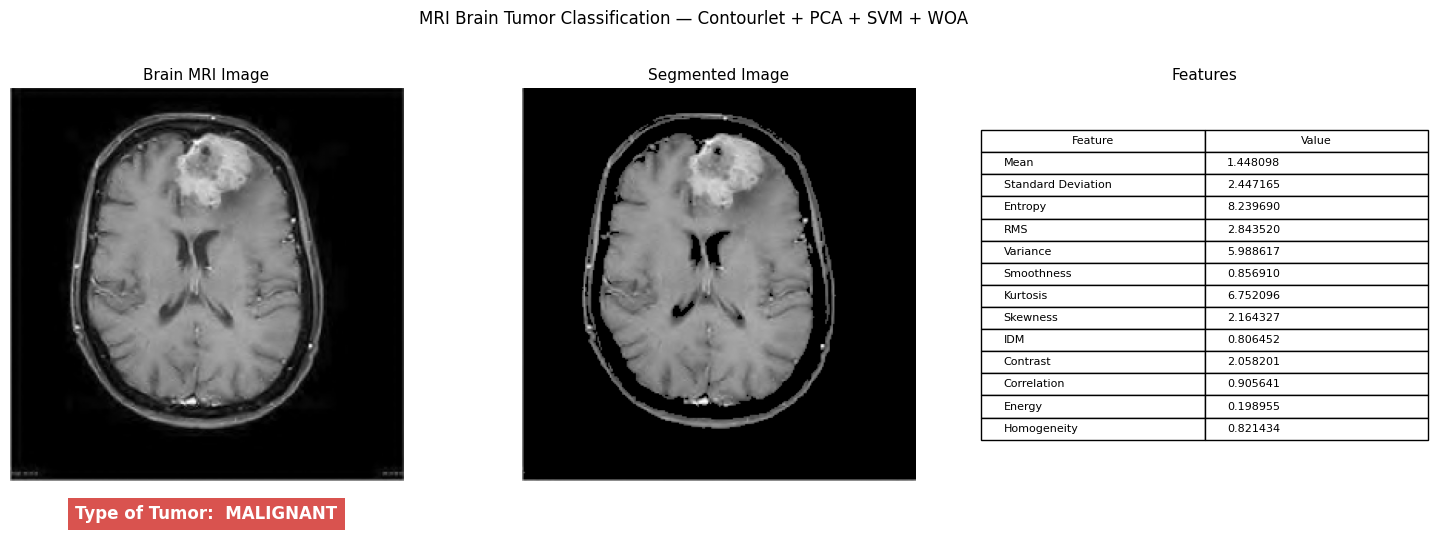


Prediction: Malignant
predict_tumor() ready.
Usage: result, feats = predict_tumor("/path/to/mri.jpg", model_bundle)


In [15]:
import matplotlib.gridspec as gridspec

FEATURE_NAMES = [
    'Mean', 'Standard Deviation', 'Entropy', 'RMS', 'Variance',
    'Smoothness', 'Kurtosis', 'Skewness', 'IDM',
    'Contrast', 'Correlation', 'Energy', 'Homogeneity'
]


def predict_tumor(img_path, model_bundle, show_output=True):
    """
    Full inference pipeline matching paper Figure 9(a).
    Shows: original MRI | segmented image | 13 features table | prediction label
    """
    # Pipeline
    img          = preprocess_mri(img_path)
    seg, _       = otsu_segment(img)
    features     = contourlet_features(seg)
    features     = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)
    scaled       = np.nan_to_num(
                       model_bundle['scaler'].transform([features]),
                       nan=0.0, posinf=0.0, neginf=0.0
                   )
    pca_feat     = model_bundle['pca'].transform(scaled)
    pred_idx     = int(model_bundle['clf'].predict(pca_feat)[0])
    pred_label   = model_bundle['classes'][pred_idx]
    display_feats = features[:13]

    if show_output:
        fig = plt.figure(figsize=(15, 5))
        gs  = gridspec.GridSpec(1, 3, width_ratios=[2, 2, 1.8])

        # Panel 1: Original MRI
        ax0 = fig.add_subplot(gs[0])
        ax0.imshow(img, cmap='gray')
        ax0.set_title('Brain MRI Image', fontsize=11)
        ax0.axis('off')
        color = '#d9534f' if pred_idx == 1 else '#5cb85c'
        ax0.text(
            0.5, -0.06,
            f'Type of Tumor:  {pred_label.upper()}',
            transform=ax0.transAxes, ha='center', va='top',
            fontsize=12, fontweight='bold', color='white',
            bbox=dict(facecolor=color, edgecolor='none', pad=5)
        )

        # Panel 2: Segmented image
        ax1 = fig.add_subplot(gs[1])
        ax1.imshow(seg, cmap='gray')
        ax1.set_title('Segmented Image', fontsize=11)
        ax1.axis('off')

        # Panel 3: 13 Feature table
        ax2 = fig.add_subplot(gs[2])
        ax2.axis('off')
        tbl = ax2.table(
            cellText  = [[n, f'{v:.6f}'] for n, v in zip(FEATURE_NAMES, display_feats)],
            colLabels = ['Feature', 'Value'],
            loc       = 'center',
            cellLoc   = 'left'
        )
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(8)
        tbl.scale(1, 1.3)
        ax2.set_title('Features', fontsize=11)

        plt.suptitle(
            'MRI Brain Tumor Classification — Contourlet + PCA + SVM + WOA',
            fontsize=12, y=1.02
        )
        plt.tight_layout()
        plt.show()
        print(f'\nPrediction: {pred_label}')

    return pred_label, display_feats


# ── Test ─────────────────────────────────────────────────────────────────────
# Replace with your image path:
result, feats = predict_tumor(
     '/content/drive/MyDrive/brain_tumor_project/dataset/mri.jpg',
     model_bundle)

print('predict_tumor() ready.')
print('Usage: result, feats = predict_tumor("/path/to/mri.jpg", model_bundle)')